# STANDARD: participant behavior, capital allocation and selling cadence

**Pinned at 2026-09-16 02:57:33 UTC, block 64,168,224, Robinhood chain 4663.**

This notebook separates observed flows, contract mechanics and assumed future behavior. It covers liquid holders, Charter owners, partial/full retirement, internal reinvestment, fresh game funding, prospective prefunding and conditional buybacks. Funding another owner gives no modeled native payout right. Locked liquidity stays in the modeled pool.

Read [the behavior map](BEHAVIOR_MAP.md) for the full decision tree and findings, and [the method](BEHAVIOR_METHOD.md) for equations and limitations. **No scenario probabilities or most-likely top are claimed.**

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd(); D=ROOT/'behavior-results'
summary=json.loads((D/'analysis-summary.json').read_text())
runs=pd.read_csv(D/'scenario-runs.csv')
paths=pd.read_csv(D/'scenario-paths.csv.gz')
display(pd.Series(summary).to_frame('snapshot / rule'))

,snapshot / rule
snapshot_utc,2026-09-16T02:57:33+00:00
block,64168224
price_ETH,0.000095
pool_principal_ETH,2223.331951
pool_principal_tokens,33383379.373083
non_protocol_wallet_tokens,62715168.746661
six_hour_seller_addresses,547
six_hour_sellers_empty,445
six_hour_seller_remaining_tokens,2421187.067972
bank_pending,1413081.801109


## 1. Observed stocks and how game purchases were funded

Wallet inventory, internal bank claims and pool reserves are distinct. Ownership does not establish buying intent. Funding lineage is pro-rata for fungible tokens; aggregate balances and license cost reconcile exactly. The 54-license follow-up spans 00:44:57–02:57:33 UTC; only about 7.8% of license spend traces to new canonical purchases.

In [2]:
display(pd.read_csv(D/'strategy-stocks.csv'))
funding=json.loads((D/'funding/followup-summary.json').read_text())
display(pd.Series({k:v for k,v in funding.items() if k.startswith('license_paid_')}).to_frame('STANDARD'))
allocation=pd.read_csv(D/'remaining-license-feasibility.csv')
display(allocation[['ledger_used','wallet_used','new_tokens_needed']].sum().to_frame('Feasible funding of remaining licenses'))

,strategy,addresses,positive_token_addresses,tokens,native_ETH_observed,bought_tokens_6h,sold_tokens_6h
0,charter_owner,941,251,9.665189e+06,2574.725042,1.489300e+06,9.943155e+05
1,inactive_holder,15429,6362,4.197418e+07,2712.941433,0.000000e+00,0.000000e+00
2,recent_buyer,269,227,9.066126e+06,726.920199,3.605989e+06,0.000000e+00
3,recent_seller,448,74,1.772924e+06,702.120842,2.128195e+05,9.218649e+06
4,two_way,74,24,2.367513e+05,122.091065,9.863124e+05,1.140185e+06


,STANDARD
license_paid_from_prior_bank_balance,308863.898785
license_paid_from_new_issuance,484.993120
license_paid_from_prefunded_wallet_tokens,806989.974316
license_paid_from_new_canonical_tokens,99416.690145
license_paid_from_new_other_custody_tokens,54003.575672


,Feasible funding of remaining licenses
ledger_used,466776.072993
wallet_used,337675.458046
new_tokens_needed,0.000000


## 2. Sale size, cadence and replacement sellers

The first-sale curve includes unsold wallets as right-censored observations. It uses snapshot-defined groups and approximate interpolated trade times: it is not a validated forward hazard. “Inactive holder” means no recent canonical activity, not no historical trade. A buy by a Charter owner is not automatically game demand.

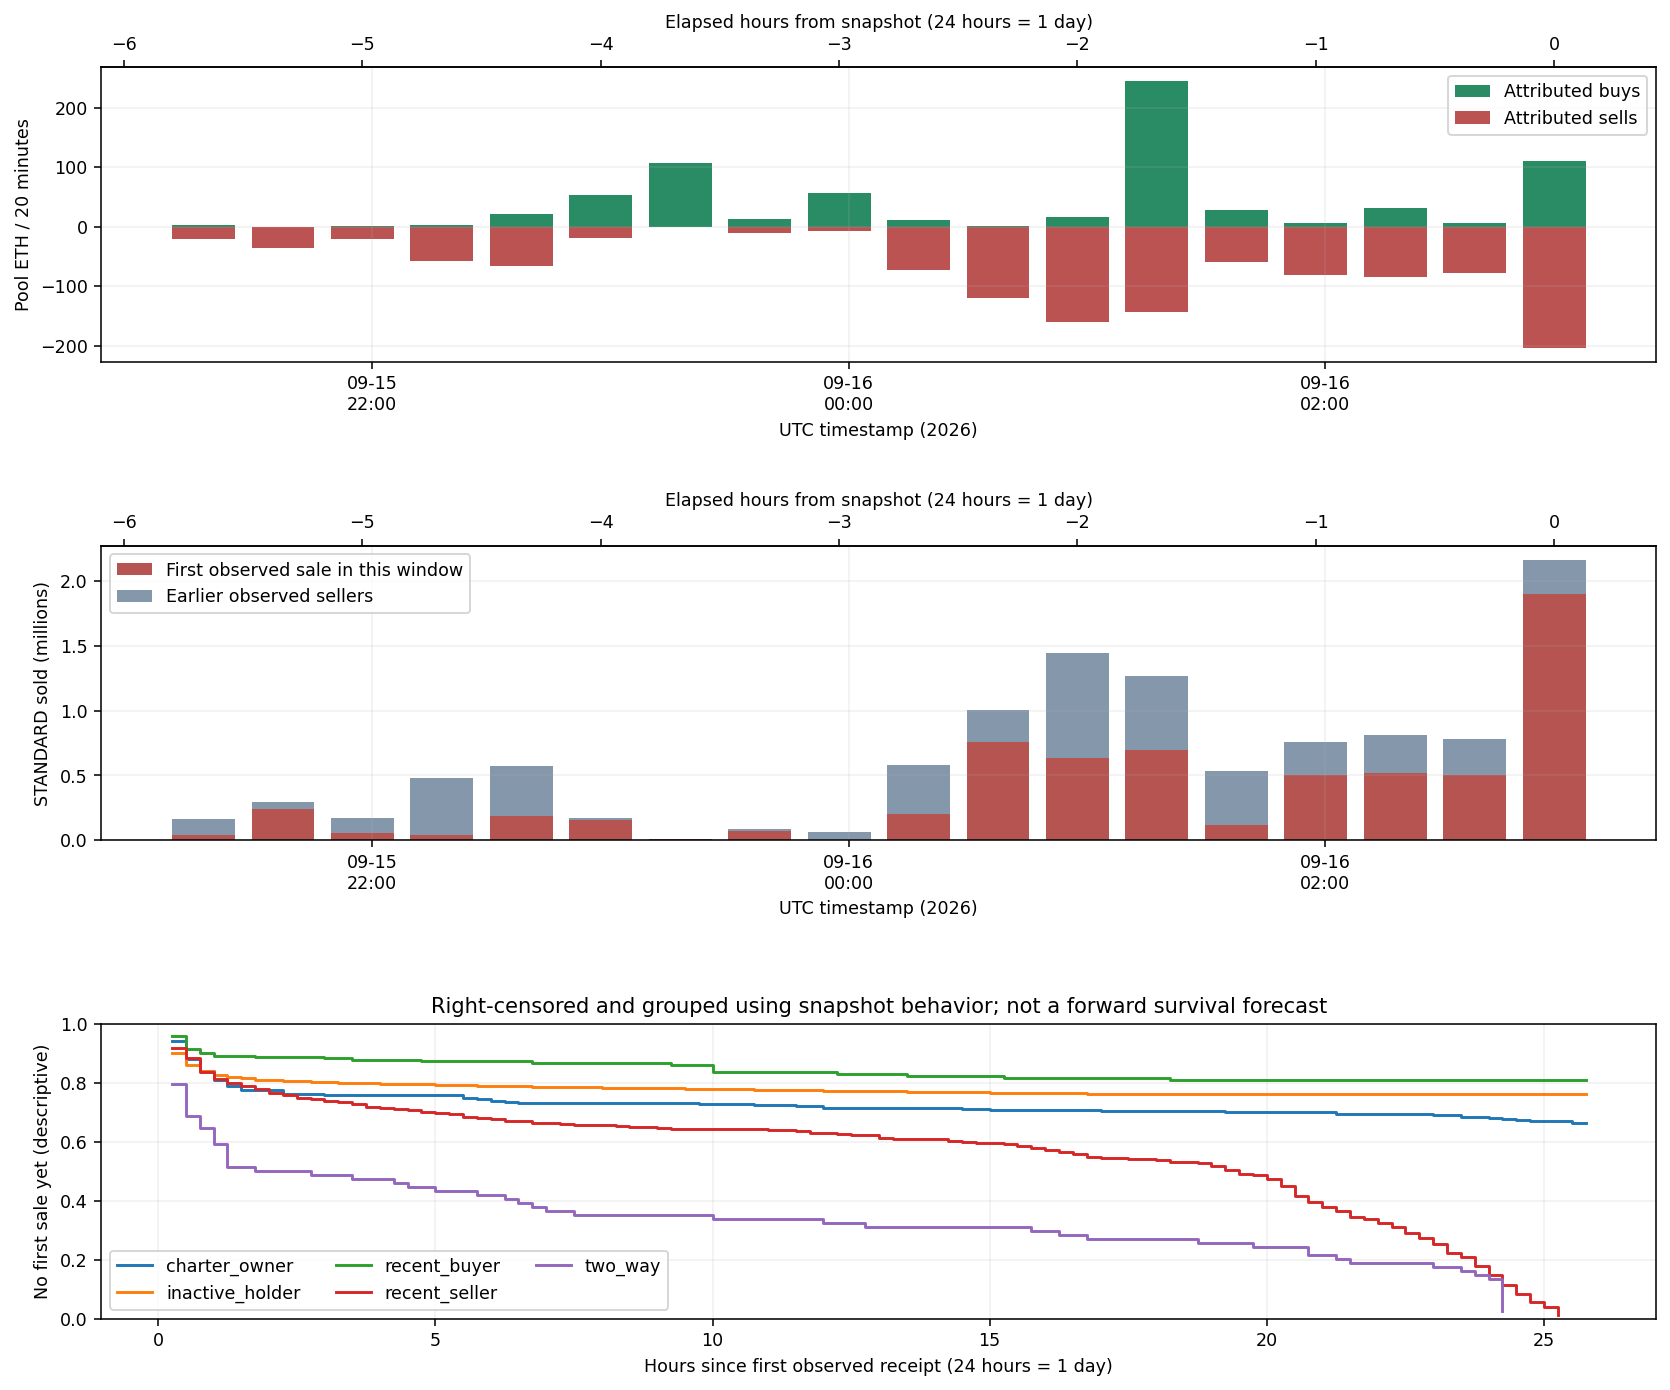

,strategy,side,trading_addresses,repeat_gap_observations,repeat_gap_p25_minutes,repeat_gap_median_minutes,repeat_gap_p75_minutes,single_trade_addresses,median_sale_fraction,full_exit_fraction_of_measured_sales
0,charter_owner,buy,268,1657,0.033769,0.254742,2.491322,71,0.500000,NaN
1,charter_owner,sell,121,562,0.052700,0.324016,4.848200,48,0.599995,0.323529
2,inactive_holder,buy,6720,16939,0.028742,0.205047,2.190650,3526,0.500000,NaN
3,inactive_holder,sell,3544,12235,0.030399,0.131846,1.545277,1958,0.500000,NaN
4,recent_buyer,buy,269,1452,0.102530,1.225802,28.891741,101,0.500000,NaN
5,recent_buyer,sell,42,514,0.067691,0.320415,1.808470,10,0.500000,NaN
6,recent_seller,buy,312,1603,0.076954,0.490086,4.133717,117,0.500000,NaN
7,recent_seller,sell,448,1057,0.122883,0.977174,14.224506,313,0.949998,0.474797
8,two_way,buy,74,672,0.031338,0.413515,18.372442,20,0.500000,NaN
9,two_way,sell,74,250,0.329874,6.651034,83.611767,36,0.974939,0.500000


,from_utc,to_utc,buy_ETH,sell_ETH,sold_tokens,new_seller_tokens,new_seller_addresses,new_buyer_ETH,new_buyer_addresses,owner_buy_ETH
12,2026-09-16T00:57:33+00:00,2026-09-16T01:17:33+00:00,245.349392,142.937846,1.268171e+06,6.947277e+05,30,30.727622,23,93.847554
13,2026-09-16T01:17:33+00:00,2026-09-16T01:37:33+00:00,27.351328,59.796716,5.337076e+05,1.144747e+05,23,1.526576,8,13.241163
14,2026-09-16T01:37:33+00:00,2026-09-16T01:57:33+00:00,6.612785,81.635004,7.579198e+05,5.048438e+05,50,0.065116,3,3.395700
15,2026-09-16T01:57:33+00:00,2026-09-16T02:17:33+00:00,30.669612,84.822608,8.153234e+05,5.211199e+05,34,0.046337,1,1.940400
16,2026-09-16T02:17:33+00:00,2026-09-16T02:37:33+00:00,6.110000,78.233870,7.779557e+05,5.039253e+05,39,1.749868,4,0.000000
17,2026-09-16T02:37:33+00:00,2026-09-16T02:57:33+00:00,110.309213,204.234911,2.166440e+06,1.900539e+06,22,16.365341,30,16.342608


,window_hours,source,sold_tokens,share_of_attributed_sold_tokens
0,0.333333,own_pool_buy,1.993778e+06,0.920301
1,0.333333,transferred_pool_buy,1.326677e+04,0.006124
2,0.333333,branch_withdrawal,0.000000e+00,0.000000
3,0.333333,transferred_branch_withdrawal,0.000000e+00,0.000000
4,0.333333,initial_allocation,0.000000e+00,0.000000
5,0.333333,transferred_allocation,0.000000e+00,0.000000
6,0.333333,other_custody_or_unresolved,1.107340e+05,0.051113
7,0.333333,own_other_pool_buy,4.820477e+04,0.022251
8,0.333333,transferred_other_pool_buy,4.568018e+02,0.000211


In [3]:
display(Image(filename=str(D/'observed-behavior.png')))
display(pd.read_csv(D/'cadence.csv'))
display(pd.read_csv(D/'flow-windows.csv').tail(6))
display(pd.read_csv(D/'participants/sell-provenance.csv').query('window_hours < 0.34'))

## 3. Conditional paths, not a probability forecast

One day = September 16, 02:57:33 UTC → September 17, 02:57:33 UTC. Each case has four seeded paths. Changing beliefs changes the willingness to use otherwise identical cash and token inventories. Endogenous re-entry recycles sale proceeds; new entrants bring separately recorded budgets. The recovery case doubles assumed newcomer arrivals, not a measured promise of future capital.

,median_return,minimum,maximum,fresh_license_ETH,prefunding_ETH,branches_retired
case,,,,,,
Observed clocks; cautious beliefs,-0.169457,-0.271302,0.139603,53.726832,300.375268,41.0
Stabilization; patient buyers,-0.015040,-0.086118,0.015679,88.239482,227.202482,9.5
Speculative recovery,0.551610,0.283410,0.693357,35.484824,322.073916,12.5
Replacement selling accelerates,-0.604287,-0.653141,-0.573125,11.277678,4.294743,53.0
Owner executes buybacks,-0.044178,-0.167325,0.144702,55.859828,316.646917,41.0
Crowded bank-exit expectations,-0.553468,-0.584845,-0.518946,1.137650,0.410530,418.0
No branch expansion,-0.236823,-0.344544,-0.007898,0.000000,0.000000,37.5
No new outside capital,-0.357971,-0.468130,-0.335853,74.857631,97.271620,37.5


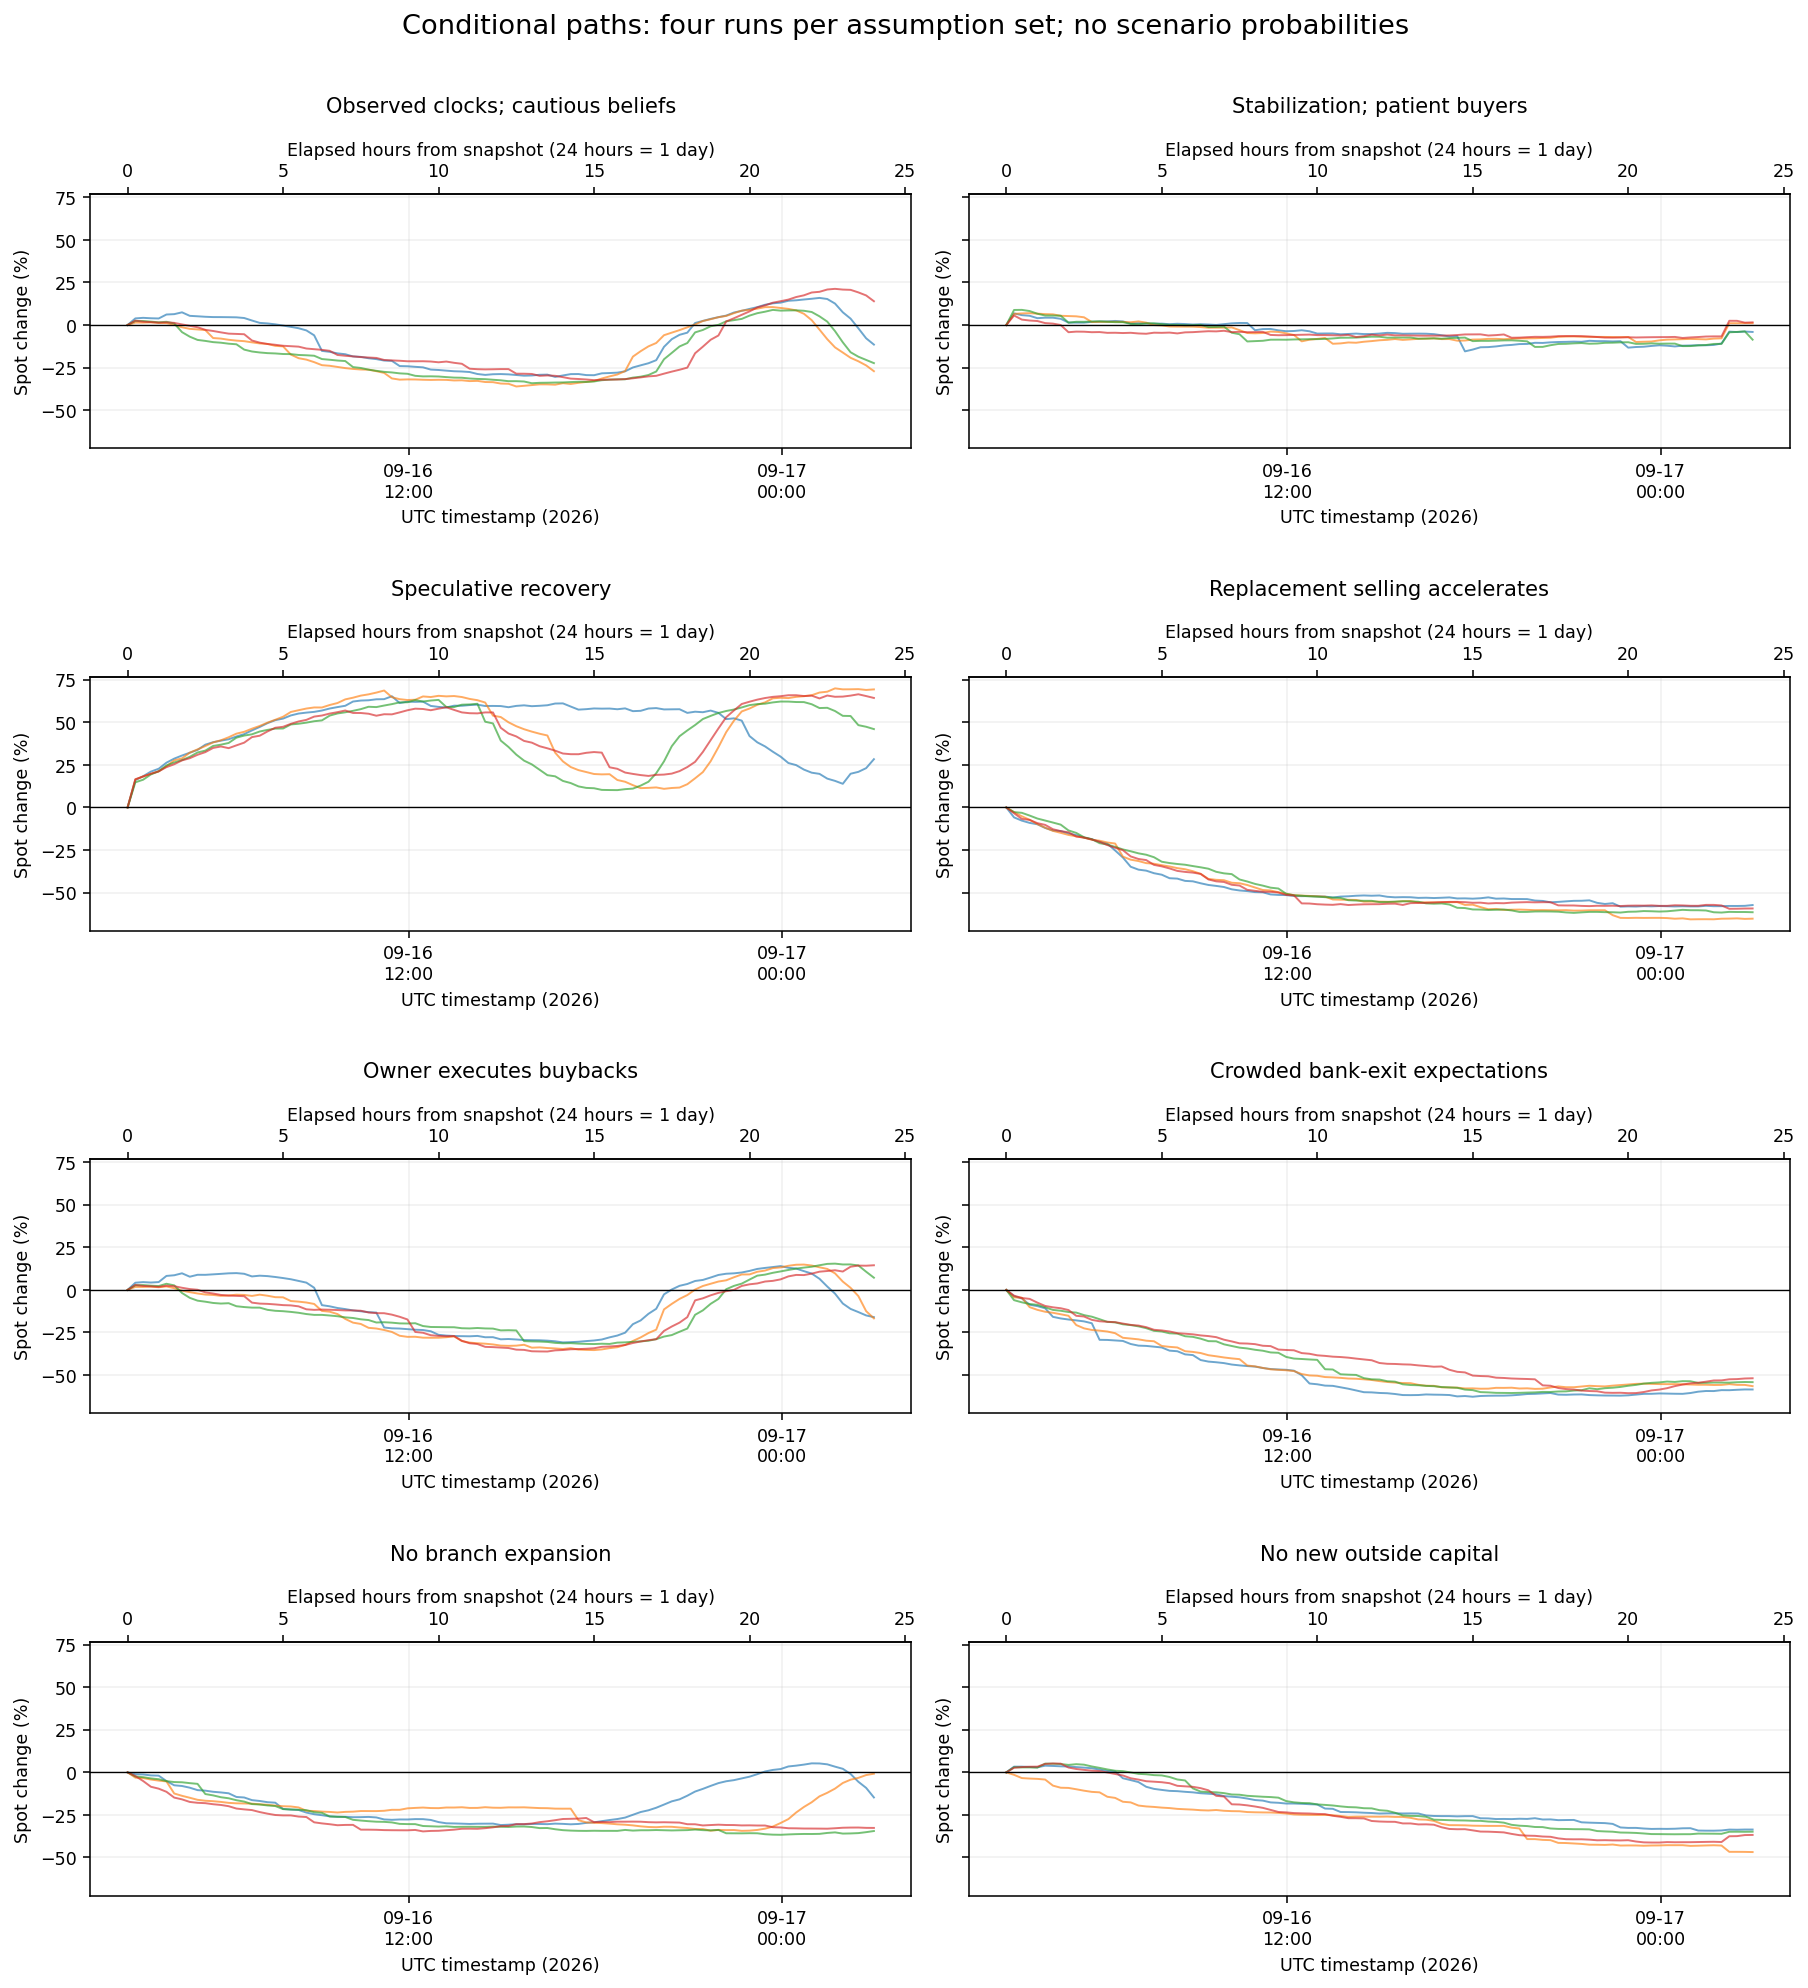

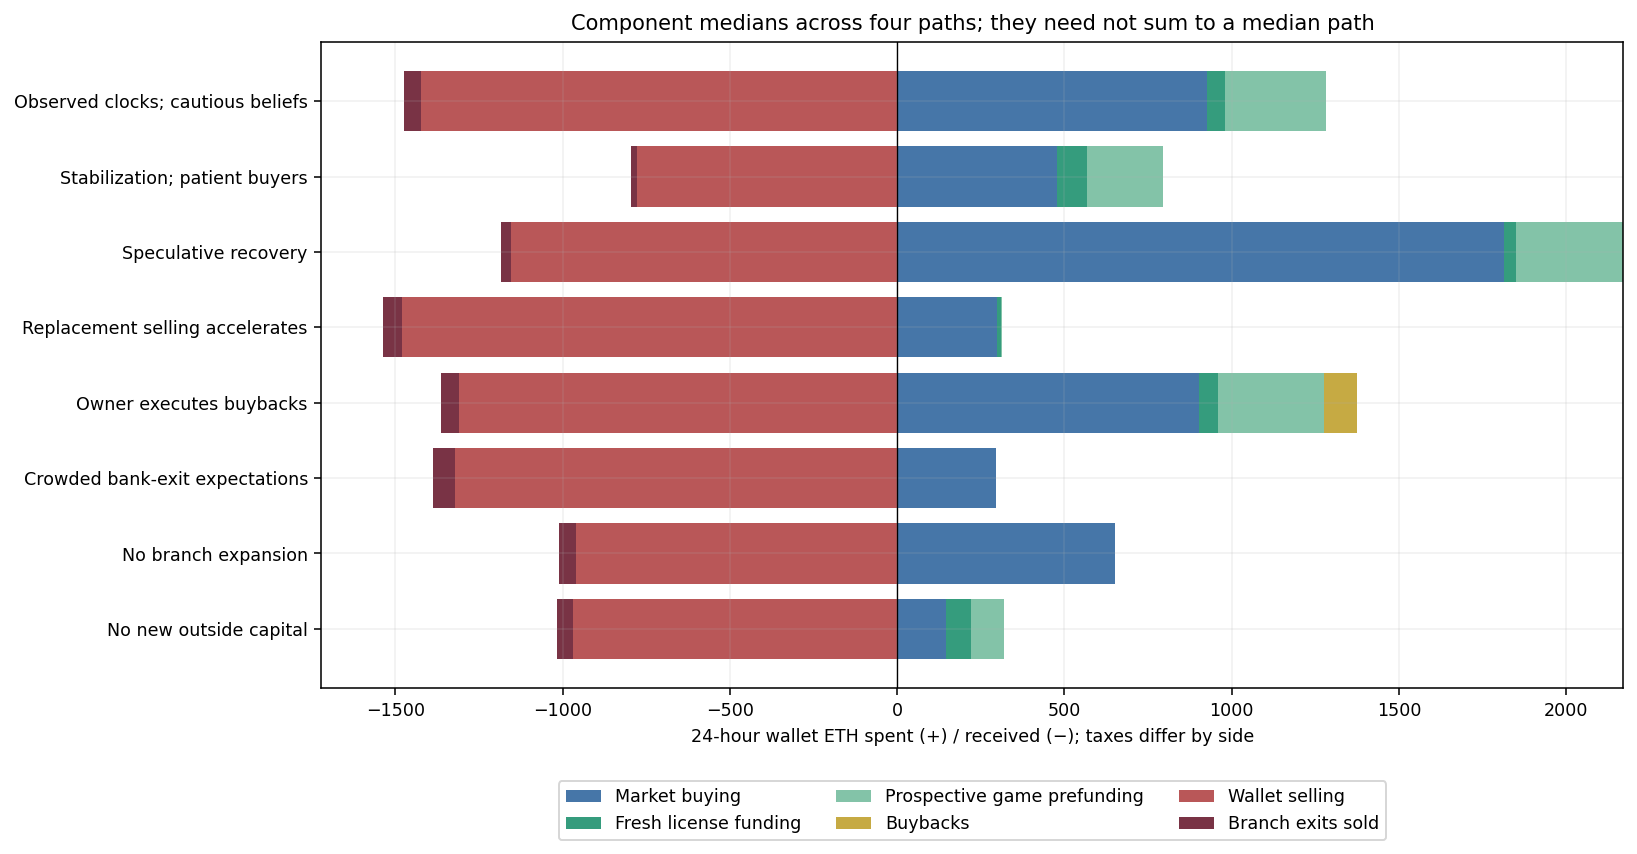

In [4]:
display(runs.groupby('case',sort=False).agg(median_return=('ending_price_return','median'),minimum=('ending_price_return','min'),maximum=('ending_price_return','max'),fresh_license_ETH=('license_fresh_ETH','median'),prefunding_ETH=('game_prefund_ETH','median'),branches_retired=('retired','median')))
display(Image(filename=str(D/'conditional-paths.png')))
display(Image(filename=str(D/'conditional-flows.png')))

## 4. Buying requirements and buybacks

These curve calculations are more direct than forecasting private beliefs. The recovery table assumes specified recent-seller inventory sells first, followed by buying to a target. It includes pool fees and hook taxes. The buyback-only worksheet assumes owner execution every hour, TWAP gates passing, no opposing sellers, no vault replenishment and a 1 ETH investor entry. No buyback has executed at the pin; no start date is verified.

In [5]:
display(pd.read_csv(D/'recovery-flow-requirements.csv').pivot(index='fraction_recent_seller_stock_sold',columns='target_spot_return',values='required_gross_buyer_ETH'))
display(pd.read_csv(D/'buyback-only-trade.csv'))

target_spot_return,0.00,0.10,0.25,0.50,1.00
fraction_recent_seller_stock_sold,,,,,
0.00,0.000000,183.975852,426.884174,775.291704,1390.658352
0.25,57.830257,241.806110,484.714431,833.121961,1448.488609
0.50,113.910187,297.886039,540.794361,889.201891,1504.568539
1.00,221.126839,405.102691,648.011013,996.418543,1611.785191


,hours,elapsed_days,timestamp_utc,buyback_spent_ETH,spot_return,one_ETH_entry_net_return
0,1,0.041667,2026-09-16T03:57:33+00:00,6.210775,0.003835,-0.065238
1,6,0.250000,2026-09-16T08:57:33+00:00,37.418666,0.020518,-0.049706
2,12,0.500000,2026-09-16T14:57:33+00:00,71.208108,0.038717,-0.032761
3,24,1.000000,2026-09-17T02:57:33+00:00,100.277523,0.054502,-0.018064


## 5. Selling cadence and precommitted exits

The 10,000-token order is an illustrative marginal liquidation quote. The 1 ETH re-entry uses the snapshot purchase quote and later executable sale quote; its crowd path is not resimulated. No horizon is selected using future prices before the decision. A hindsight price peak is a descriptive statistic, not an optimal policy. UTC and elapsed hours/days are both retained.

In [6]:
exits=pd.read_csv(D/'precommitted-exit-worksheet.csv')
display(exits[exits.seed==0].pivot(index=['hours','elapsed_days','timestamp_utc'],columns='case',values='new_one_ETH_entry_net_return'))
display(runs[['case','seed','hindsight_peak_hours','hindsight_peak_utc','peak_return']])
events=pd.read_csv(D/'case-1-events.csv')
events['elapsed_days']=events.hour/24
events['timestamp_utc']=(pd.Timestamp(summary['snapshot_utc'])+pd.to_timedelta(events.hour,unit='h')).astype(str)
display(events.head(20))

,,case,Crowded bank-exit expectations,No branch expansion,No new outside capital,Observed clocks; cautious beliefs,Owner executes buybacks,Replacement selling accelerates,Speculative recovery,Stabilization; patient buyers
hours,elapsed_days,timestamp_utc,,,,,,,,
0.0,0.000000,2026-09-16T02:57:33+00:00,-0.068809,-0.068809,-0.068809,-0.068809,-0.068809,-0.068809,-0.068809,-0.068809
1.0,0.041667,2026-09-16T03:57:33+00:00,-0.157427,-0.086760,-0.041029,-0.033114,-0.025983,-0.160752,0.142737,-0.031523
3.0,0.125000,2026-09-16T05:57:33+00:00,-0.341760,-0.178593,-0.053627,-0.025625,0.018928,-0.256293,0.296324,-0.049954
6.0,0.250000,2026-09-16T08:57:33+00:00,-0.425248,-0.297667,-0.178120,-0.125223,-0.056936,-0.472736,0.453743,-0.066116
12.0,0.500000,2026-09-16T14:57:33+00:00,-0.632323,-0.356992,-0.293911,-0.337078,-0.338926,-0.550105,0.485513,-0.115593
24.0,1.000000,2026-09-17T02:57:33+00:00,-0.613386,-0.206008,-0.381523,-0.175883,-0.217852,-0.602473,0.195004,-0.106783


,case,seed,hindsight_peak_hours,hindsight_peak_utc,peak_return
0,Observed clocks; cautious beliefs,0,22.25,2026-09-17T01:12:33+00:00,0.159116
1,Observed clocks; cautious beliefs,1,20.75,2026-09-16T23:42:33+00:00,0.105064
2,Observed clocks; cautious beliefs,2,20.75,2026-09-16T23:42:33+00:00,0.088744
3,Observed clocks; cautious beliefs,3,22.75,2026-09-17T01:42:33+00:00,0.212398
4,Stabilization; patient buyers,0,0.25,2026-09-16T03:12:33+00:00,0.068236
5,Stabilization; patient buyers,1,0.75,2026-09-16T03:42:33+00:00,0.069502
6,Stabilization; patient buyers,2,0.50,2026-09-16T03:27:33+00:00,0.088918
7,Stabilization; patient buyers,3,0.25,2026-09-16T03:12:33+00:00,0.055919
8,Speculative recovery,0,8.50,2026-09-16T11:27:33+00:00,0.653073
9,Speculative recovery,1,22.75,2026-09-17T01:42:33+00:00,0.699391


,hour,event,charter_id,count,gross_tokens,resolution_fee,price_tokens,internal_tokens,wallet_tokens,fresh_tokens,elapsed_days,timestamp_utc
0,0.0,retire,747,1.0,12573.137958,0.020352,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
1,0.0,retire,444,1.0,11686.647958,0.020766,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
2,0.0,retire,297,1.0,13786.647958,0.021457,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
3,0.0,retire,589,1.0,78760.647958,0.029634,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
4,0.0,retire,786,1.0,12578.997958,0.031606,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
5,0.0,retire,814,1.0,12575.547958,0.033761,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
6,0.0,retire,277,2.0,15891.311005,0.036747,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
7,0.0,retire,92,1.0,24866.647958,0.042007,NaN,NaN,NaN,NaN,0.0,2026-09-16 02:57:33+00:00
8,0.0,license,644,NaN,NaN,NaN,17488.076762,111.662966,17376.413795,0.000000,0.0,2026-09-16 02:57:33+00:00
9,0.0,license,337,NaN,NaN,NaN,17488.076762,116.842966,17371.233795,0.000000,0.0,2026-09-16 02:57:33+00:00


## 6. What is and is not validated

Balance conservation and caps are tested. Price forecasting is not validated. The simple prior-hour-flow holdout illustrates instability; it is not an out-of-sample test of this agent model. The step-size and action-order variants also change results materially. Four paths per case and two per sensitivity do not support statistical confidence claims.

In [7]:
display(pd.read_csv(D/'persistence-holdout.csv'))
display(pd.read_csv(D/'assumption-sensitivity.csv')[['case','seed','ending_price_return','license_fresh_ETH','game_prefund_ETH','retired']])
errors=pd.read_csv(D/'accounting.csv.gz')
display(errors[['ETH_error','token_error','ledger_error']].abs().max().to_frame('Maximum absolute accounting error'))
assert errors.ETH_error.abs().max()<1e-5
assert errors.token_error.abs().max()<.03
assert errors.ledger_error.abs().max()<1e-5
assert len(runs)==32
assert summary['remaining_licenses_feasible_fresh_tokens']==0

,metric,forecast_from_utc,predicted_next_hour,observed_next_hour,absolute_error
0,buy_ETH,2026-09-15T21:57:33+00:00,3.281875e+00,7.557516e+01,7.229329e+01
1,sell_ETH,2026-09-15T21:57:33+00:00,7.768816e+01,1.427833e+02,6.509511e+01
2,new_seller_tokens,2026-09-15T21:57:33+00:00,3.373117e+05,3.836654e+05,4.635363e+04
3,buy_ETH,2026-09-15T22:57:33+00:00,7.557516e+01,1.757879e+02,1.002127e+02
4,sell_ETH,2026-09-15T22:57:33+00:00,1.427833e+02,1.938545e+01,1.233978e+02
5,new_seller_tokens,2026-09-15T22:57:33+00:00,3.836654e+05,7.923293e+04,3.044324e+05
6,buy_ETH,2026-09-15T23:57:33+00:00,1.757879e+02,2.850316e+01,1.472847e+02
7,sell_ETH,2026-09-15T23:57:33+00:00,1.938545e+01,3.511802e+02,3.317948e+02
8,new_seller_tokens,2026-09-15T23:57:33+00:00,7.923293e+04,1.586338e+06,1.507105e+06
9,buy_ETH,2026-09-16T00:57:33+00:00,2.850316e+01,2.793135e+02,2.508103e+02


,case,seed,ending_price_return,license_fresh_ETH,game_prefund_ETH,retired
0,Wallet actions first,0,-0.070016,104.915261,176.609997,34
1,Wallet actions first,1,-0.253259,46.649037,300.145682,50
2,Half-sized time step,0,-0.213703,43.743742,303.674273,44
3,Half-sized time step,1,0.063446,153.354970,292.327213,35
4,No speculative game prefunding,0,-0.077795,160.871167,0.000000,30
5,No speculative game prefunding,1,-0.270708,46.679922,0.000000,45
6,Seven-day branch valuation,0,-0.146879,9.261060,64.135593,28
7,Seven-day branch valuation,1,0.033246,14.459778,80.907861,38


,Maximum absolute accounting error
ETH_error,5.161382e-11
token_error,8.832722e-07
ledger_error,1.635635e-08


## 7. Edit assumptions and run your own offline case

`prior_growth_day` is a subjective log-price-growth belief, not a forecast. `new_capital_multiplier` scales assumed arrival intensity. Previously inactive wallets have a separate activation process. Prices depend on all of these choices and on the actual liquidity curve. Set the switch below to `True` to run; it is off so opening/executing the shared notebook does not launch another scenario batch.

Limits include unknown motives, unmeasured outside wealth, no secondary-route execution, idle POL, assumed owner attention, no gas/MEV, a finite continuation grid and no Nash-equilibrium solution. The model does not promise that rational actors correctly predict one another.

In [8]:
from behavior_model import Config,Economy
custom=Config(name='My conditional case',hours=24,prior_growth_day=-.03,new_capital_multiplier=1.,seller_activation_multiplier=1.,execute_buybacks=False,valuation_days=60,prefund_enabled=True)
RUN_CUSTOM=False
if RUN_CUSTOM:
    economy=Economy(custom,seed=123)
    custom_path,custom_events,custom_accounting=economy.run()
    display(custom_path)
else:
    display(pd.Series(vars(custom)).to_frame('Editable assumptions'))

,Editable assumptions
name,My conditional case
hours,24
dt_hours,0.25
prior_growth_day,-0.03
belief_dispersion,0.08
momentum_weight,0.15
reversion_share,0.35
new_capital_multiplier,1.0
seller_activation_multiplier,1.0
buyer_activity_multiplier,1.0
